# Different methods of estimating a parameter posterior with PCGPs

In [1]:
import jax.numpy as jnp
import jax
import torch
import gpytorch
import numpyro.distributions as dist 
import matplotlib.pyplot as plt
from functools import partial
import sympy as sp

from PCGP import PCGP_Builder, PCGP_Builder_jax

from PCGP.gpytorch.LaplaceApprox import laplace_approx
import PCGP.jax.grid as grid
import PCGP.jax.numpyro as mcmc


jax.config.update("jax_enable_x64", True)
seed = jax.random.key(0)
rng_key = jax.random.PRNGKey(0)
torch.set_default_dtype(torch.float64)
torch.manual_seed(5)

import os #only necessary for jupyter nb
output_dir = os.path.join(os.path.dirname(os.getcwd()), "Tutorial_InverseProblem") #only necessary for jupyter nb

# Prerequisites: Model and Data
For simplicity, we will choose a very simple model with 1 physical parameter a. The differential equation is the following: 
$$ a f_1' = f_2$$
Which leads to the matrix form $Af = 0$ with $A = (a\partial, -1)$ and $f = (f_1, f_2)^T$. The corresponding $B$-Matrix is $B = (1, a\partial)^T$.

For the experiments, we choose a groundtruth $a = 2$, $f_1 = \sin(x)$, $f_2 = 2\cos(x)$.
We add Gaussian Noise of $\sigma$, and the training set consists of $N$ points of each function. For visualization, we test on $10N$ points. 

In [2]:
def B(D, x):
    a = sp.Symbol("a")
    return sp.matrices.Matrix([[1     ],
                               [a*D[0]] ])

In [3]:
sigma = 0.1
N = 10
train_x_0 = torch.linspace(0,2*torch.pi,N)
train_x_1 = torch.linspace(0,2*torch.pi,N)
train_i_0 = torch.zeros_like(train_x_0)
train_i_1 = torch.ones_like(train_x_1)
train_x = torch.concatenate([train_x_0, train_x_1])
train_i = torch.cat([train_i_0, train_i_1])
full_train_x = torch.stack([train_x, train_i], dim=-1) #data must have structure N x (d+1); N = total number of data points, d = dimensions, 1=index to specify task
train_y_0 = torch.sin(train_x_0)+sigma*torch.randn_like(train_x_0)
train_y_1 = 2*torch.cos(train_x_1)+sigma*torch.randn_like(train_x_1)
train_y = torch.cat([train_y_0, train_y_1])
test_x_0 = torch.linspace(0,2*torch.pi,N*10)
test_x_1 = torch.linspace(0,2*torch.pi,N*10)
test_i_0 = torch.zeros_like(test_x_0)
test_i_1 = torch.ones_like(test_x_1)
test_x = torch.cat([test_x_0, test_x_1])
test_i = torch.cat([test_i_0, test_i_1])
full_test_x = torch.stack([test_x, test_i], dim=-1)

# Baseline: Standard Bayesian Parameter estimation

In the standard Bayesian parameter estimation, we use the ground truth structure directly as our model, with the only unknown being the value of a (i.e. f_1 = sin(x), f_2 = a*cos(x)). We assume a Gaussian likelihood with noise $\sigma^2$, i.e. p(train_y|a, full_train_x) = $\propto \exp(-distance^2/(2\sigma^2))$ with $distance^2 = ||model(train_x) - train_y||^2 = (\sum_{i\in train_{i_0}} sin(x_i) - y_i)^2 + (\sum_{i\in train_{i_1}} a \cos(x_i) - y_i)^2$. For now we will use a flat prior for $a$ between a_min and a_max, but feel free to play around and define different priors. We can calculate the normalization numerically. 

This is the optimal case since there is no model uncertainty. 

In [5]:
a_min = 0
a_max = 4
a_n = 200
a_vals = torch.linspace(a_min, a_max, a_n)
da = float(a_vals[1]-a_vals[0])

#prior
def flat_prior(a_vals):
    prior = torch.zeros_like(a_vals)
    mask = (a_vals >= 0) & (a_vals <= 4)
    prior[mask] = 1/4
    return prior
    
prior = flat_prior(a_vals)   

#data for likelihood
model_y_0 = torch.sin(train_x_0).expand(len(a_vals), -1)
model_y_1 = a_vals[:, None]*torch.cos(train_x_1)[None, :] 
model_y = torch.cat([model_y_0, model_y_1], dim=1)          
distance_squared = torch.sum((model_y - train_y[None, :])**2, dim=1) 
likelihood = torch.exp(-distance_squared / (2 * sigma**2))

#posterior
posterior = likelihood * prior
baseline_posterior = posterior / (posterior.sum() * da)


Text(0.5, 1.0, 'Ground truth')

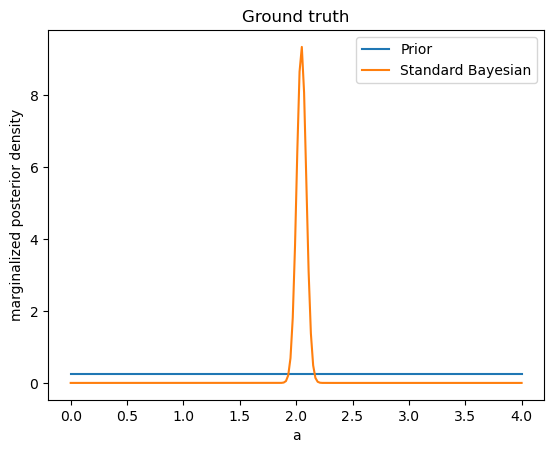

In [6]:
#plotting
plt.plot(a_vals, prior, label = "Prior")
plt.plot(a_vals, baseline_posterior, label = "Standard Bayesian")
plt.xlabel("a")
plt.ylabel("marginalized posterior density")
plt.legend()
plt.title("Ground truth")

# Exercises:
- play around with the prior! How does the posterior change?
- change the number of data points or the noise level. How does the posterior change now?

# Version 1: Optimizing + Laplace Approximation with GPyTorch

Step 1: Write kernel and model in GPyTorch

In [4]:
builder = PCGP_Builder()
builder.add_kernel(B,  number_of_input_dimensions=1, shared_base_kernel = True)
builder.write("Ver1_LaplaceApprox", output_dir) #specifying output dir only necessary for jupyter nb

Kernel and model written to: /home/johanna/Documents/PhD/project/github/PCGP/Tutorials/Tutorial_InverseProblem/Ver1_LaplaceApprox.py


Step 2: Import the written file. 

Step 3: (Optional) Specify which parameters should be trained and which fixed, as well as constraints. The structure is that of a dictionary containing parameters you want to modify from default as keys and a list containing [initial values, optimized/fixed, Constraints]. Per default, all parameters are optimized and the only constraints are positivity constraints on lengthscale and amplitude. 

Step 4: Specify the noise level for each point (if you want it to be fixed which I would recommend), as well as the likelihood (FixedNoiseGaussianLikelihood or GaussianLikelihood), and the model. Priors can optionally be specified in the model. Attention: Flat priors can effectively also be fixed using Constraints only. If you do choose priors, you must make sure that the constraint has the exact same scope as the prior (i.e. Gaussian prior = No constraint!; log-normal prior = positive constraint, flat specified prior = Interval constraint etc) otherwise GPyTorch will throw an error. 

In [5]:
import Ver1_LaplaceApprox as ver1
priors = None#{"a": gpytorch.priors.UniformPrior(0, 4.)}
according_to_prior = False#gpytorch.constraints.Interval(0, 4)
#alternative: priors = None, according_to_prior = False
modified_parameters = { "a": [2., True, False], #according_to_prior], 
                        "lengthscale":[6., True, gpytorch.constraints.Positive()], 
                        "amplitude":[1., True, gpytorch.constraints.Positive()]}
            

noise_tensor = sigma**2*torch.ones(train_y.shape[0])
likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise = noise_tensor)              #to check format of noise                                                                                                                 
model = ver1.PCGP_Model(full_train_x, train_y, likelihood, modified_parameters, priors = priors)

Step 5: Training. Change N_training and learning rate (lr) until loss convergence is assured. (You can store and plot the loss curve to be sure). Attention: the marginal_log_likelihood provided by gpytorch actually calculates the marginal log likelihood DIVIDED by the number of trainin points, so to get the correct Laplace approximation, we need to multiply the loss by the number of training points. 

In [7]:
model.train()
likelihood.train()
N_training = 101
optimizer = torch.optim.Adam(model.named_parameters(), lr=0.1)
marginal_log_likelihood  = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
for i in range(N_training):
                optimizer.zero_grad()
                output = model(full_train_x)
                loss = -marginal_log_likelihood(output, train_y)*train_y.shape[0]
                if i%100==0 :
                    print("iteration: ", i, "loss:", loss.item())
                loss.backward(retain_graph = True)
                optimizer.step()
optimizer.zero_grad()
output = model(full_train_x)  
final_loss = -marginal_log_likelihood(output, train_y)*train_y.shape[0]


iteration:  0 loss: -1.5055570521848445
iteration:  100 loss: -1.505540816743462


Step 6: Extract the MAP estimators (optimized parameters) and calculate the covariance matrix of the laplace approximation based on (converged!!! otherwise wrong) the gradient of the loss w.r.t. the optimized parameters. The hessian is the (actually calculated and thus more exact) inverse of the covariance matrix.

In [12]:
laplace_approximation = laplace_approx(modified_parameters, model, final_loss)
covariance, hessian, parameter_index = laplace_approximation.covariance, laplace_approximation.hessian, laplace_approximation.parameter_index
MAP_estimates = laplace_approximation.MAP_estimates

Step 7: Calculate posterior distribution and plot it using the obtained covariance/hessian. This posterior has 3 dimensions and is thus hard to visualize. You can for example marginalize over the calibration parameters "amplitude" and "lengthscale" by only using the corresponding block matrix entry o'f the covariance matrix (attention: here you CANNOT use the block matrix of the hessian!)

Text(0.5, 1.0, 'Laplace posterior')

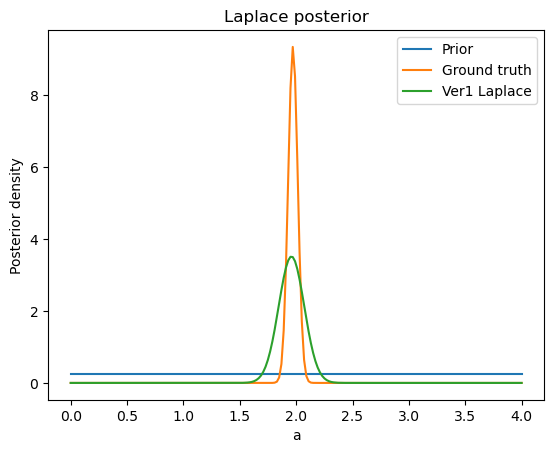

In [ ]:
marginal = torch.distributions.Normal(MAP_estimates[parameter_index["a"]], torch.sqrt(covariance[parameter_index["a"], parameter_index["a"]]))
density_ver1 = torch.exp(marginal.log_prob(a_vals))
density_ver1 /= torch.sum(density_ver1*da)

plt.plot(a_vals, prior, label = "Prior")
plt.plot(a_vals, baseline_posterior, label = "Ground truth")
plt.plot(a_vals, density_ver1, label = "Ver1 Laplace")
plt.xlabel("a")
plt.ylabel("Posterior density")
plt.legend()
plt.title("Laplace posterior")


# Exercises
- Read up what the Laplace Approximation is! Why can we use the loss function to calculate it?
- What actually is the "marginal log likelihood"? Why is it called marginal? Why likelihood? What is actually calculated?
- Play around and see what happens if you fix calibration parameters (amplitude and lengthscale) to some values. Why didn't we use them in the ground truth calculation?
- Try to also plot the marginalized distributions for the other parameters, and the joint distribution of the amplitude and lengthscale (either marginalized over "a", or conditioned on a fixed "a"). What do you observe?
- What are the advantages and disadvantages of the Laplace Approximation?

# Version 2: Grid Evaluation with jax
Step 1: Analogous to gpytorch, build the kernel first, then import it for the following calculations. 

In [11]:
builder = PCGP_Builder_jax()
builder.add_kernel(B,  number_of_input_dimensions=1, shared_base_kernel = True)
builder.write("Ver2_GridEvaluation", output_dir = output_dir)

You are using the new version of the generator, which is still experimental. If you encounter any issues, please report them to the developer.
Kernel and model written to: /home/johanna/Documents/PhD/project/github/PCGP/Tests/Ver2_GridEvaluation.py


Since our data has been in torch format for the last version, we need to recast it to jax. Jax does not like dynamically built kernels, so we need to tell the kernel the data structure and compile it beforehand (this gives us a speedup of about 10x).

In [12]:
import Ver2_GridEvaluation as ver2

full_train_x_jax = jnp.array(full_train_x)
train_y_jax = jnp.array(train_y)
full_test_y_jax = jnp.array(full_test_x)

structure = grid.build_structure(full_train_x_jax, full_train_x_jax, num_groups=2)
compiled_kernel = jax.jit(partial(ver2.kernel, structure=structure))

Since we would like to simply evaluate the margianl log likelihood (in the in the previous exercises discussed sense) on a grid, we need to define meshgrids (i.e. all parameter combinations) and flatten them into a dictionary that we can use to evaluate the mll at those points. To get all parameters on different axis again, we can then reshape the mll output. This makes it easier to calculate marginals (i.e. sum up over parameters we don't care about). 

In [13]:
a_vals_jax = jnp.array(a_vals) #same as above for easy comparison
lengthscale_vals = jnp.linspace(0.1, 10, 10)#jnp.array([1,  5, 10.]) 
amplitude_vals = jnp.linspace(0.1, 10, 10)#jnp.array([1, 10., 100]) 
grids = jnp.meshgrid(a_vals_jax, lengthscale_vals, amplitude_vals, indexing="ij")
params = {"a": grids[0].flatten(), "lengthscale": grids[1].flatten(), "amplitude": grids[2].flatten()}
mll_values = grid.mll(params, full_train_x_jax, train_y_jax, sigma, compiled_kernel)
mll_reshaped = mll_values.reshape(grids[0].shape)

<class 'jax._src.interpreters.batching.BatchTracer'>


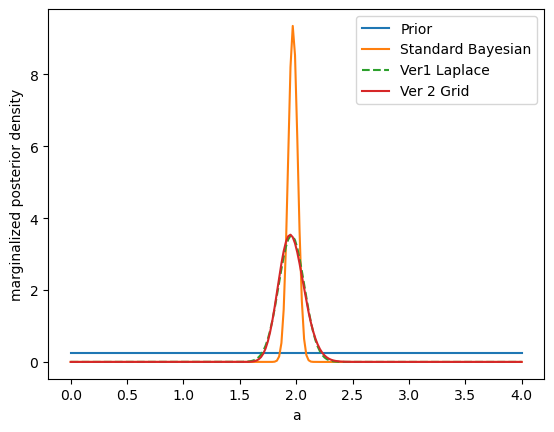

In [18]:
marginal_posterior = jnp.exp(jax.scipy.special.logsumexp(mll_reshaped, axis=(1, 2)))
density_ver2 = marginal_posterior/jnp.sum(marginal_posterior*da)


plt.plot(a_vals, prior, label = "Prior")
plt.plot(a_vals, baseline_posterior, label = "Standard Bayesian")
plt.plot(a_vals, density_ver1, "--", label = "Ver1 Laplace")
plt.plot(a_vals, density_ver2, label = "Ver 2 Grid")
plt.xlabel("a")
plt.ylabel("marginalized posterior density")
plt.legend()

# Exercises
- What problem does grid evaluation have in many dimensions?
- What is the logsumexp trick and why do we use it?
- Try also plotting a conditional likelihood (for example the probability of a given lengthscale = 1 and amplitude = 2). Play around a bit!

# Version 3: MCMC Sampling with jax and NumPyro

Because grid sampling is not feasible in high dimensions, a standard way of approximating the posterior is Markov-Chain Monte Carlo sampling. It is exact in the limes of infinite samples - but since you need many samples it is also time-and computation power consuming. The preparation steps are the same as in grid sampling. You additionally need to specify initial values from where to start, and here, priors are NOT optional. 

In [19]:
init_values = {"a": .5, "lengthscale": .5, "amplitude": .5}
priors = {"a": dist.Uniform(0.000, 4), "lengthscale": dist.Uniform(0.001, 10), "amplitude": dist.Uniform(0.001, 10)} #choosing a flat prior for all parameters  

  
compiled_model = mcmc.build_model(compiled_kernel, priors = priors)
samples = mcmc.run_inference(compiled_model, 
                             rng_key, #pse
                             full_train_x_jax, 
                             train_y_jax, 
                             num_samples =1000, 
                             sigma = sigma,
                             priors = priors,
                             init_values = init_values,
                             fixed_params={})

sample: 100%|█| 2000/2000 [00:03<00:00, 539.31it/s, 15 steps of size 4.15e-01. a



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
            a      1.97      0.12      1.95      1.78      2.15    593.25      1.00
    amplitude      3.95      2.47      3.42      0.53      7.75    417.48      1.00
  lengthscale      5.40      1.44      5.41      3.03      7.74    417.87      1.00

Number of divergences: 0
MCMC elapsed time: 5.780368328094482


Marginalizing over samples is simply taking all samples of the parameter you want to keep. For Conditioning, you would need to only make a histogram over the samples of parameter a, where the samples of the other parameters have a certain value. 

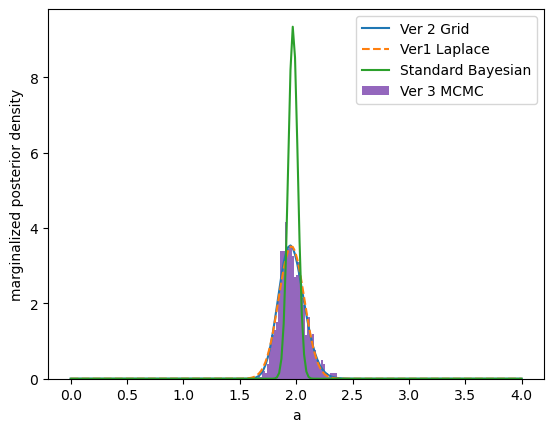

In [20]:
density_ver3, bin_edges = jnp.histogram(samples["a"], bins = a_vals.shape[0], range = (a_vals[0], a_vals[-1]), density = True)
plt.bar((bin_edges[1:]+bin_edges[:-1])/2, density_ver3, width = da, color = "C4", label = "Ver 3 MCMC")
plt.plot(a_vals, density_ver2, label = "Ver 2 Grid")
plt.plot(a_vals, density_ver1, "--", label = "Ver1 Laplace")
#plt.plot(a_vals, get_prior(a_vals), label = "Prior")
plt.plot(a_vals, baseline_posterior, label = "Standard Bayesian")
plt.xlabel("a")
plt.ylabel("marginalized posterior density")
plt.legend()

# Exercises
- Get a (very!) short overview what MCMC is (no need for equations).
- Find out what happens if you define differnt priors
- Play around with the number of samples. What does the analytics-value"n_eff" mean?

# Version 4: Sampling with DIRT+TensorTrains
That's where you come in :) 